# Fit data

In [32]:
import numpy as np
def fit_model(x, y, degree=1):
    """
    Fit a polynomial

    Parameters
    x : array-like
        Input data
    y : array-like
        Output data
    degree : int
        Degree of polynomial (1, 2, or 3)

    Returns
    poly : numpy.poly1d
        Polynomial function
    """

    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)
    return poly


In [33]:
def volt_to_inch(v, model):
    """
    Convert voltage to predicted inches using chosen model.

    Parameters
    v : float or array-like
        Voltage value(s)
    model: numpy.poly1d
        Polynomial function

    Returns
    float or array
        Predicted inches
    """
    return model(v)


# print("Linear fit:")
# print(linear_model)

# print("2nd degree fit:")
# print(quad_model)

# print("3rd degree fit:")
# print(cubic_model)

In [34]:
# Example usage
import pandas as pd
# load from csv or enter data manually
#loading from csv
df = pd.read_csv('example_volt.csv')
inches = df["inch"]
volts = df["volt"]

#entering manually
# inches = [1,2,3,4,5,6,7,8,9,10]
# volts = [0.1 ,0.23,0.45 ,0.67 ,1.0 ,1.2 ,1.4 ,1.7 ,1.9, 2.15]

linear_model = fit_model(volts, inches, degree=1)
quad_model = fit_model(volts, inches, degree=2)
cubic_model = fit_model(volts, inches, degree=3)

x = 2  # voltage value
print(f"For voltage = {x}:")
print("Linear result:", volt_to_inch(x, linear_model))
print("2nd degree result:", volt_to_inch(x, quad_model))
print("3rd degree result:", volt_to_inch(x, cubic_model))

For voltage = 2:
Linear result: 9.401067179846045
2nd degree result: 9.34979292561884
3rd degree result: 9.3495084780733



Predicted inches over time for all models:
 time  volt  predicted_linear_(degree_1)  predicted_quadratic_(degree_2)  predicted_cubic_(degree_3)
    1   0.4                     2.616603                        2.612104                    2.692826
    2   2.0                     9.401067                        9.349793                    9.349508
    3   0.3                     2.192573                        2.166377                    2.204028
    4   1.5                     7.280922                        7.323923                    7.227352
    5   1.0                     5.160777                        5.225637                    5.269385
    6   0.0                     0.920486                        0.811816                    0.585428
    7   0.3                     2.192573                        2.166377                    2.204028
    8   0.3                     2.192573                        2.166377                    2.204028
    9   0.6                     3.464661       

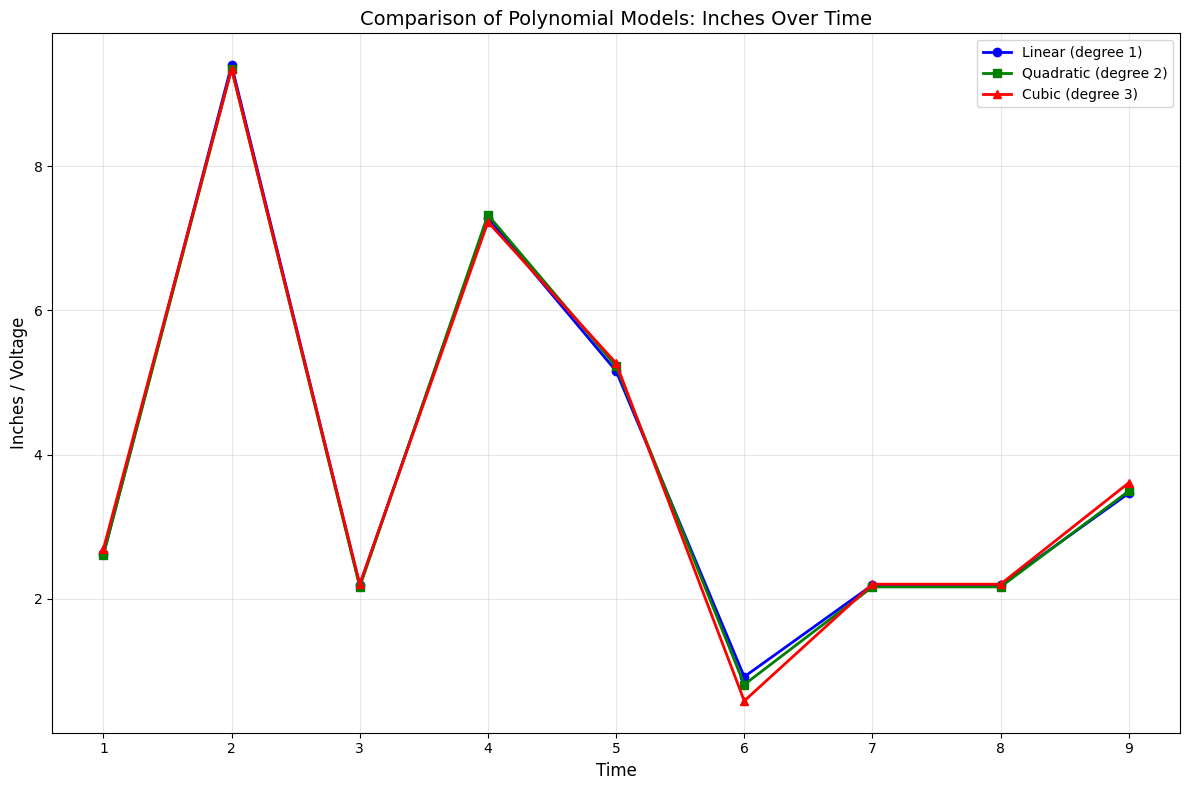

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Example of using it on csv and graphing
df_data = pd.read_csv('example_data.csv')
time = df_data["time"] # REPLACE THESE NAMES WITH THE ACTUAL COLUMN NAMES FOR TESTING
time_volts = df_data["volt"]

# load from csv or enter data manually
#loading from csv
df = pd.read_csv('example_volt.csv')
inches = df["inch"]
volts = df["volt"]

#entering manually
# inches = [1,2,3,4,5,6,7,8,9,10]
# volts = [0.1 ,0.23,0.45 ,0.67 ,1.0 ,1.2 ,1.4 ,1.7 ,1.9, 2.15]


models = [
    (fit_model(volts, inches, degree=1), "Linear (degree 1)"),
    (fit_model(volts, inches, degree=2), "Quadratic (degree 2)"),
    (fit_model(volts, inches, degree=3), "Cubic (degree 3)")
]

results_df = pd.DataFrame({"time": time, "volt": time_volts})

for model, model_name in models:
    predicted_inches = [volt_to_inch(v, model) for v in time_volts]
    results_df[f"predicted_{model_name.replace(' ', '_').lower()}"] = predicted_inches

print("\nPredicted inches over time for all models:")
print(results_df.to_string(index=False))

plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']
for i, (model, model_name) in enumerate(models):
    pred_col = f"predicted_{model_name.replace(' ', '_').lower()}"
    plt.plot(time, results_df[pred_col], 
             marker=markers[i], 
             color=colors[i], 
             label=model_name,
             linewidth=2,
             markersize=6)


plt.xlabel("Time", fontsize=12)
plt.ylabel("Inches / Voltage", fontsize=12)
plt.title("Comparison of Polynomial Models: Inches Over Time", fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()